In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [22]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Dataset/CMAPSSData'
TRAIN_PATH = f'{DATA_DIR}/train_FD001.txt'
TEST_PATH = f'{DATA_DIR}/test_FD001.txt'
RUL_PATH = f'{DATA_DIR}/RUL_FD001.txt'

RUL_CAP = 125
ROLL_WINDOWS = (5, 10)
LAGS = (1, 2, 3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
columns = [
    'unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

train_df = pd.read_csv(TRAIN_PATH, sep=r'\s+', header=None, names=columns)
test_df = pd.read_csv(TEST_PATH, sep=r'\s+', header=None, names=columns)
true_rul = pd.read_csv(RUL_PATH, sep=r'\s+', header=None, names=['RUL'])

print('train shape:', train_df.shape)
print('test shape :', test_df.shape)
print('rul shape  :', true_rul.shape)

train shape: (20631, 26)
test shape : (13096, 26)
rul shape  : (100, 1)


In [24]:
max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max().rename('max_cycles')
train_df = train_df.merge(max_cycles, left_on='unit_number', right_index=True)
train_df['RUL'] = train_df['max_cycles'] - train_df['time_in_cycles']
train_df = train_df.drop(columns=['max_cycles'])

train_df['RUL_pw'] = train_df['RUL'].clip(upper=RUL_CAP)
print('RUL max raw      :', train_df['RUL'].max())
print('RUL max piecewise:', train_df['RUL_pw'].max())

RUL max raw      : 361
RUL max piecewise: 125


In [25]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_std = train_df[sensor_cols].std()
keep_sensors = sensor_std[sensor_std >= 0.01].index.tolist()
drop_sensors = sensor_std[sensor_std < 0.01].index.tolist()

print(f'Keeping {len(keep_sensors)} sensors, dropping {len(drop_sensors)} sensors')
print('Dropped sensors:', drop_sensors)

Keeping 14 sensors, dropping 7 sensors
Dropped sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [26]:
def add_rolling_features(df, sensors, windows=(5, 10)):
    out = df.copy().sort_values(['unit_number', 'time_in_cycles'])
    for w in windows:
        grp = out.groupby('unit_number', group_keys=False)
        rm = grp[sensors].rolling(window=w, min_periods=1).mean().reset_index(level=0, drop=True)
        rs = grp[sensors].rolling(window=w, min_periods=1).std().fillna(0.0).reset_index(level=0, drop=True)
        rm.columns = [f'{c}_rm{w}' for c in sensors]
        rs.columns = [f'{c}_rs{w}' for c in sensors]
        out = out.join(rm).join(rs)
    return out


def add_lag_diff_features(df, sensors, lags=(1, 2, 3)):
    out = df.copy().sort_values(['unit_number', 'time_in_cycles'])
    grp = out.groupby('unit_number', group_keys=False)

    for lag in lags:
        lag_vals = grp[sensors].shift(lag)
        lag_vals.columns = [f'{c}_lag{lag}' for c in sensors]
        out = out.join(lag_vals)

    d1 = grp[sensors].diff(1).fillna(0.0)
    d1.columns = [f'{c}_d1' for c in sensors]
    out = out.join(d1)

    return out.fillna(0.0)

In [27]:
train_fe = add_rolling_features(train_df, keep_sensors, windows=ROLL_WINDOWS)
test_fe = add_rolling_features(test_df, keep_sensors, windows=ROLL_WINDOWS)

train_fe = add_lag_diff_features(train_fe, keep_sensors, lags=LAGS)
test_fe = add_lag_diff_features(test_fe, keep_sensors, lags=LAGS)

print('train_fe shape:', train_fe.shape)
print('test_fe shape :', test_fe.shape)

train_fe shape: (20631, 140)
test_fe shape : (13096, 138)


In [28]:
test_last = test_fe.groupby('unit_number', as_index=False).last()
true_rul_eval = true_rul.copy()
true_rul_eval['unit_number'] = np.arange(1, len(true_rul_eval) + 1)
test_last = test_last.merge(true_rul_eval, on='unit_number', how='inner')

feature_cols = [c for c in train_fe.columns if c not in ['unit_number', 'time_in_cycles', 'RUL', 'RUL_pw']]

X_train = train_fe[feature_cols].fillna(0.0)
y_train = train_fe['RUL_pw']
X_test = test_last[feature_cols].fillna(0.0)
y_test = test_last['RUL']
groups = train_fe['unit_number']

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train max  :', y_train.max())
print('rolling sample:', [c for c in X_train.columns if '_rm5' in c][:5])

X_train shape: (20631, 136)
X_test shape : (100, 136)
y_train max  : 125
rolling sample: ['sensor_2_rm5', 'sensor_3_rm5', 'sensor_4_rm5', 'sensor_7_rm5', 'sensor_8_rm5']


In [29]:
def evaluate_model(model_name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'--- {model_name} ---')
    print(f'RMSE: {rmse:.2f} cycles')
    print(f'MAE : {mae:.2f} cycles')
    print(f'R^2 : {r2:.3f}\n')
    return rmse

In [30]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])
rf_base = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=15,
    tree_method='hist',
    device='cuda',
    random_state=42
)

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
rf_base.fit(X_train, y_train)
rf_base_pred = rf_base.predict(X_test)

_ = evaluate_model('Linear Regression', y_test, lr_pred)
rf_base_rmse = evaluate_model('Random Forest baseline', y_test, rf_base_pred)

--- Linear Regression ---
RMSE: 21.40 cycles
MAE : 16.97 cycles
R^2 : 0.735

--- Random Forest baseline ---
RMSE: 21.54 cycles
MAE : 15.75 cycles
R^2 : 0.731



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [04:15:24] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [31]:
rf_strong = xgb.XGBRegressor(
    n_estimators=1200,
    max_depth=10,
    learning_rate=0.05,
    tree_method='hist',
    device='cuda',
    random_state=42
)

rf_strong.fit(X_train, y_train)
rf_strong_pred = rf_strong.predict(X_test)
rf_strong_rmse = evaluate_model('Random Forest strong', y_test, rf_strong_pred)

--- Random Forest strong ---
RMSE: 20.20 cycles
MAE : 14.39 cycles
R^2 : 0.764



In [32]:
cv = GroupKFold(n_splits=3)

param_dist = {
    'n_estimators': [300, 500, 800],
    'max_depth': [6, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.5, 0.8, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(tree_method='hist', device='cuda', random_state=42),
    param_distributions=param_dist,
    n_iter=8,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=42,
    verbose=2,
    n_jobs=1,
    pre_dispatch='2*n_jobs'
)

rf_search.fit(X_train, y_train, groups=groups)
print('Best CV RMSE:', -rf_search.best_score_)
print('Best params:', rf_search.best_params_)

rf_tuned = rf_search.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_rmse = evaluate_model('Random Forest tuned', y_test, rf_tuned_pred)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=15, n_estimators=500, subsample=0.8; total time=  30.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=15, n_estimators=500, subsample=0.8; total time=  28.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=15, n_estimators=500, subsample=0.8; total time=  31.3s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=6, n_estimators=300, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=6, n_estimators=300, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=6, n_estimators=300, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, n_estimators=800, subsample=1.0; total time=   3.9s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, n_estimators=800, subsample=1.0; total time=   4.0s
[CV] END col

In [33]:
et_model = xgb.XGBRegressor(
    n_estimators=1200,
    max_depth=12,
    subsample=0.8,
    colsample_bytree=0.5,
    tree_method='hist',
    device='cuda',
    random_state=42
)

et_model.fit(X_train, y_train)
et_pred = et_model.predict(X_test)
et_rmse = evaluate_model('ExtraTrees', y_test, et_pred)

results = pd.DataFrame({
    'model': ['RF_baseline', 'RF_strong', 'RF_tuned', 'ExtraTrees'],
    'rmse': [rf_base_rmse, rf_strong_rmse, rf_tuned_rmse, et_rmse]
}).sort_values('rmse')
print(results)

--- ExtraTrees ---
RMSE: 21.34 cycles
MAE : 15.41 cycles
R^2 : 0.736

         model       rmse
2     RF_tuned  19.395840
1    RF_strong  20.202143
3   ExtraTrees  21.340576
0  RF_baseline  21.538137


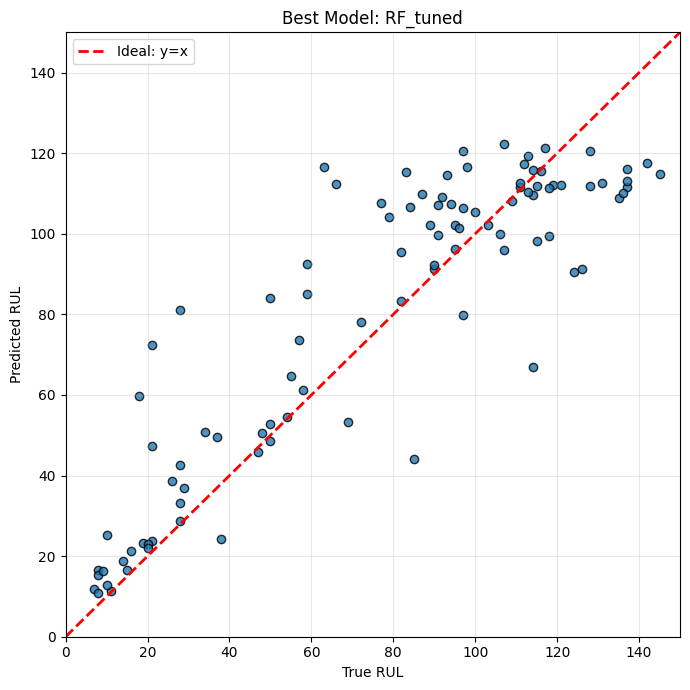

In [34]:
best_name = results.iloc[0]['model']
if best_name == 'RF_tuned':
    best_pred = rf_tuned_pred
elif best_name == 'ExtraTrees':
    best_pred = et_pred
elif best_name == 'RF_strong':
    best_pred = rf_strong_pred
else:
    best_pred = rf_base_pred

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_pred, alpha=0.8, edgecolors='k')
lims = [0, max(y_test.max(), best_pred.max()) + 5]
plt.plot(lims, lims, 'r--', linewidth=2, label='Ideal: y=x')
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')
plt.title(f'Best Model: {best_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()